In [ ]:
# Import Python libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Load Dataset: Average Income & Rent in the United States**

In [ ]:
data = pd.read_csv("Average Income and Rent in United States.csv")

**Data Inspection**

In [ ]:
data.head()
data.info()
data.describe(include='all')

# This is where I begin understanding data quality before cleaning and analysis

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   State           50 non-null     object
 1   Average_Rent    50 non-null     object
 2   Average_Income  50 non-null     object
dtypes: object(3)
memory usage: 1.3+ KB


,State,Average_Rent,Average_Income
count,50,50,50
unique,50,48,50
top,Alabama,$829,"$50,637"
freq,1,2,1


In [ ]:
print(data.columns)

# Display the column names in the dataset (This is when I noticed that for the states the label was "Region" and changed that column to "State")
# Useful for confirming correct spelling and detecting spaces or formatting issues (I also was able to find that the data had symbols and commas, which I removed below.)
# Helps ensure we reference the right column names during cleaning and analysis


Index(['State', 'Average_Rent', 'Average_Income'], dtype='object')


**Cleaning up the data - Goal is to remove the symbols and commas that can keep me from completing my analysis.**

In [ ]:
data['Average_Income'] = data['Average_Income'].replace('[\$,]', '', regex=True).astype(float)
data['Average_Rent'] = data['Average_Rent'].replace('[\$,]', '', regex=True).astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-2423592273.py:1: SyntaxWarning: invalid escape sequence '\$'
  data['Average_Income'] = data['Average_Income'].replace('[\$,]', '', regex=True).astype(float)
/tmp/ipython-input-2423592273.py:2: SyntaxWarning: invalid escape sequence '\$'
  data['Average_Rent'] = data['Average_Rent'].replace('[\$,]', '', regex=True).astype(float)


In [ ]:
data['Rent_to_Income_Ratio'] = (data['Average_Rent'] * 12) / data['Average_Income'] * 100
# This turned the rent affordability into a percentage based on the average price of rent and the average income.

**Data Exploration**

In [ ]:
data.describe() # Display descriptive statistics for all the numbers and provide an overview.

,Average_Rent,Average_Income,Rent_to_Income_Ratio
count,50.000000,50.00000,50.000000
mean,1055.220000,62776.54000,20.089608
std,287.682669,9044.03668,4.100447
min,752.000000,46248.00000,13.870422
25%,847.250000,56892.00000,17.627037
50%,951.500000,61246.00000,19.621733
75%,1220.250000,68160.75000,21.448075
max,2036.000000,84972.00000,39.937883


Average Rent Across U.S. States

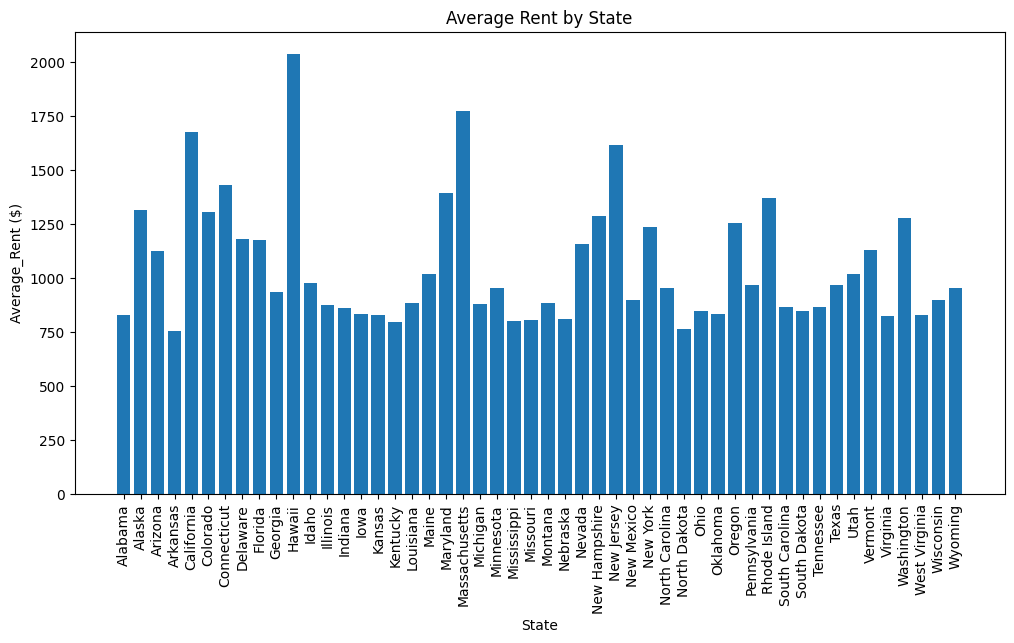

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(data['State'], data['Average_Rent'])
plt.xticks(rotation=90)
plt.title("Average Rent by State")
plt.xlabel("State")
plt.ylabel("Average_Rent ($)")
plt.show()

# Visualize how average rent varies across all 50 states
# A bar chart helps compare state-to-state differences in housing costs

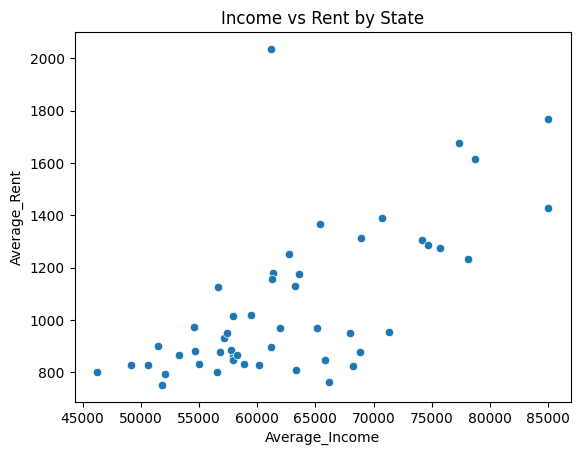

In [ ]:
sns.scatterplot(x='Average_Income', y='Average_Rent', data=data)
plt.title("Income vs Rent by State")
plt.show()

# Scatterplot showing the relationship between average income and average rent

Rent Burden by State (Rent-to-Income Ratio)

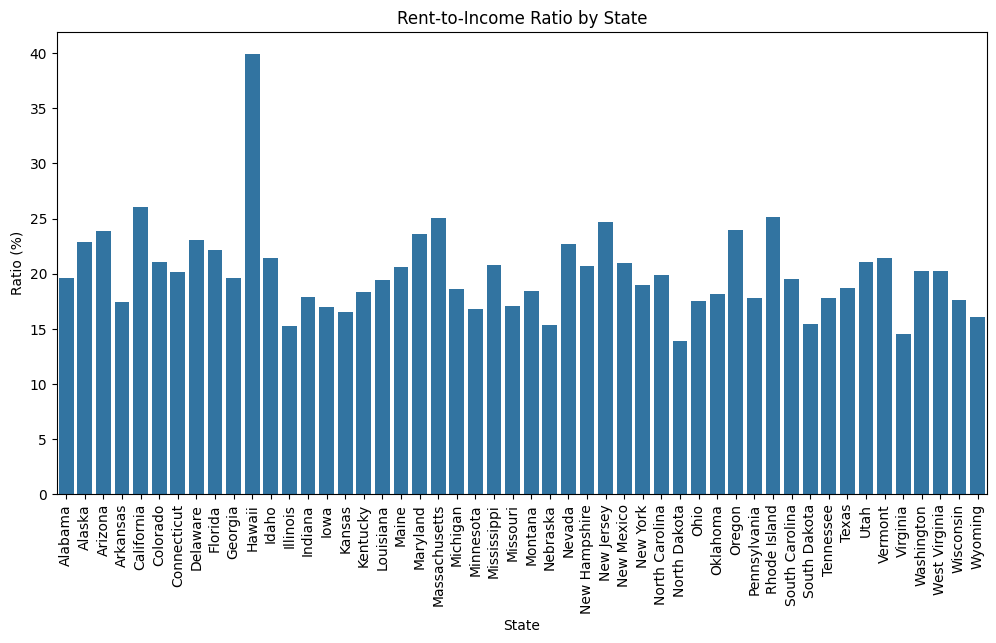

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x='State', y='Rent_to_Income_Ratio', data=data)
plt.xticks(rotation=90)
plt.title("Rent-to-Income Ratio by State")
plt.ylabel("Ratio (%)")
plt.show()

# Bar chart showing how much of annual income is spent on rent in each state


Income vs Rent Split by Income Group

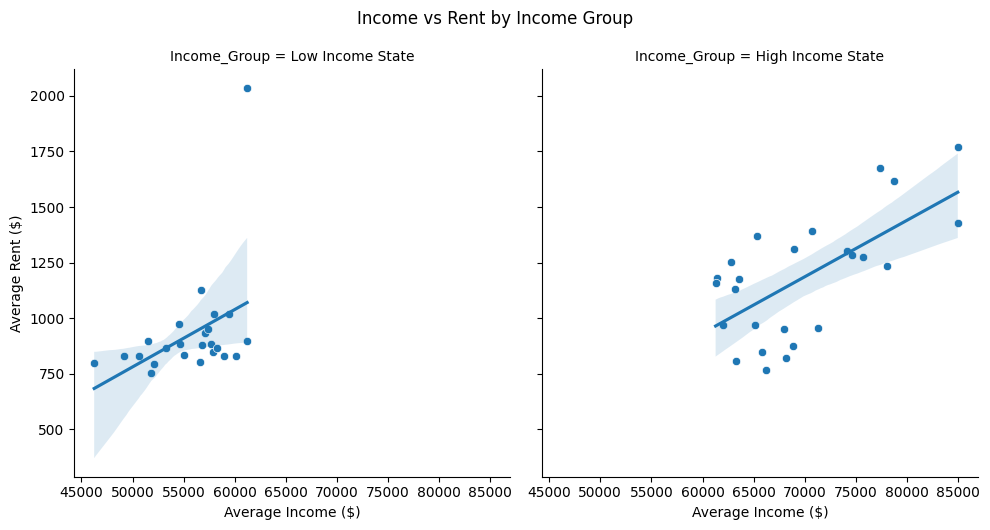

In [ ]:
# Compare income/rent relationships across income groups
# The dataset is split into High Income vs Low Income states based on median income
# Each part shows how rent changes with income within that group

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv("Average Income and Rent in United States.csv")

data["Average_Income"] = (
    data["Average_Income"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

data["Average_Rent"] = (
    data["Average_Rent"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

data["Rent_to_Income_Ratio"] = (data["Average_Rent"] / data["Average_Income"]) * 100


median_income = data["Average_Income"].median()

data["Income_Group"] = np.where(
    data["Average_Income"] >= median_income,
    "High Income State",
    "Low Income State"
)


g = sns.FacetGrid(data, col="Income_Group", height=5, aspect=1)
g.map_dataframe(sns.scatterplot, x="Average_Income", y="Average_Rent")
g.map_dataframe(sns.regplot, x="Average_Income", y="Average_Rent", scatter=False)

g.set_axis_labels("Average Income ($)", "Average Rent ($)")
g.fig.suptitle("Income vs Rent by Income Group", y=1.05)
plt.show()




**Predicitive Analytics and Modeling**

Simple Linear Regression: Predicting Rent from Income

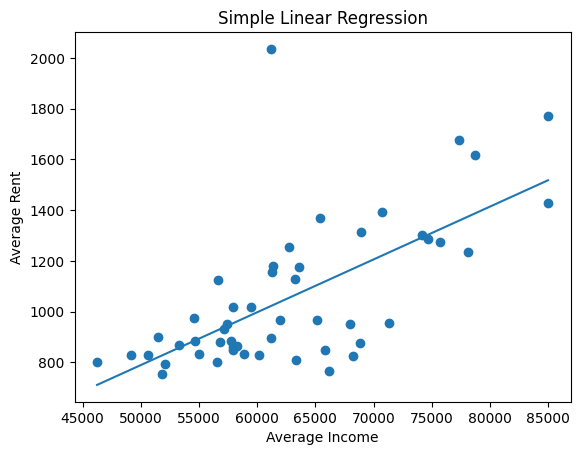

In [ ]:
# This model estimates how much rent increases for each additional dollar of income
# The regression line helps visualize the overall linear relationship across all states

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

df = pd.read_csv("Average Income and Rent in United States.csv")


df["Income"] = (
    df["Average_Income"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

df["Rent"] = (
    df["Average_Rent"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Assign x and y
x = df["Income"].values.reshape(-1, 1)
y = df["Rent"].values

# linear regression
model = LinearRegression()
model.fit(x, y)

# Predict line for plotting
x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
y_line = model.predict(x_line)


plt.scatter(x, y)
plt.plot(x_line, y_line)
plt.xlabel("Average Income")
plt.ylabel("Average Rent")
plt.title("Simple Linear Regression")
plt.show()


**Interpretation and Insights**

Slope (m): 0.020845
Intercept (b): -253.34

For every extra $10,000 in income, predicted rent increases by about $208.45.

Correlation (r) between income and rent: 0.655
R^2 (variance in rent explained by income): 0.429
This suggests a strong positive relationship: states with higher incomes tend to have higher rents.

States with rents HIGHER than predicted (more expensive for their income):
- Hawaii: actual rent $2036, model expected $1022
- California: actual rent $1677, model expected $1359
- Rhode Island: actual rent $1368, model expected $1109
- Massachusetts: actual rent $1770, model expected $1517
- New Jersey: actual rent $1617, model expected $1387

States with rents LOWER than predicted (cheaper for their income):
- North Dakota: actual rent $765, model expected $1126
- Virginia: actual rent $823, model expected $1168
- Illinois: actual rent $876, model expected $1181
- Wyoming: actual rent $954, model expected $1234
- South Dakota: actual rent $848, model expected $1118


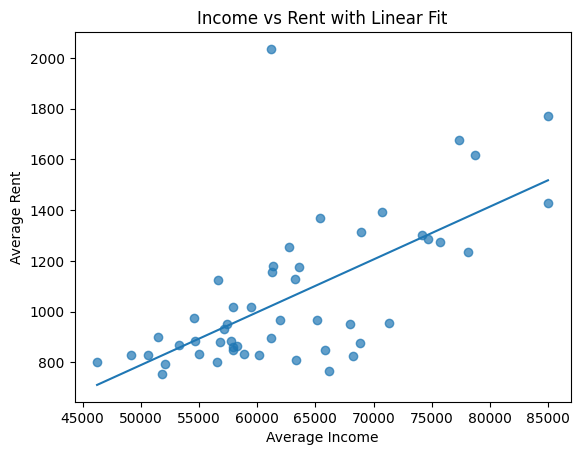

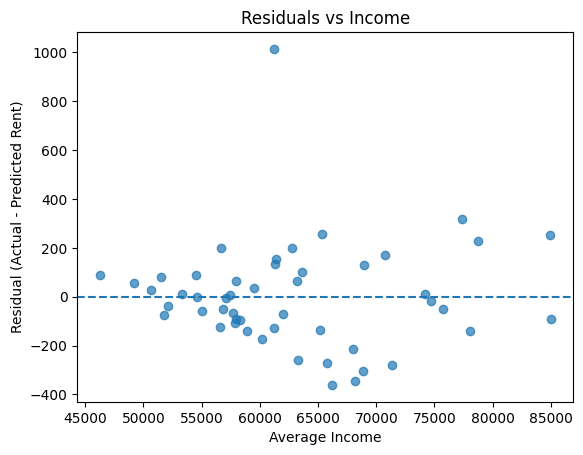

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Average Income and Rent in United States.csv")

df["Income"] = (
    df["Average_Income"]
      .str.replace("$", "", regex=False)
      .str.replace(",", "", regex=False)
      .astype(float)
)

df["Rent"] = (
    df["Average_Rent"]
      .str.replace("$", "", regex=False)
      .str.replace(",", "", regex=False)
      .astype(float)
)

# The slope (m) shows how rent changes with income across states
# The intercept (b) represents expected rent when income is zero

x = df["Income"].values
y = df["Rent"].values

m, b = np.polyfit(x, y, 1)
y_pred = m * x + b

print(f"Slope (m): {m:.6f}")
print(f"Intercept (b): {b:.2f}")

# Interpretation of slope: change in rent for $10,000 more income
rent_per_10k = m * 10_000
print(f"\nFor every extra $10,000 in income, "
      f"predicted rent increases by about ${rent_per_10k:.2f}.")

r_matrix = np.corrcoef(x, y)
r = r_matrix[0, 1]
r2 = r**2

print(f"\nCorrelation (r) between income and rent: {r:.3f}")
print(f"R^2 (variance in rent explained by income): {r2:.3f}")

if abs(r) < 0.3:
    strength = "weak"
elif abs(r) < 0.6:
    strength = "moderate"
else:
    strength = "strong"

direction = "positive" if r > 0 else "negative"
print(f"This suggests a {strength} {direction} relationship: "
      f"states with higher incomes tend to have higher rents.")


# Defining which states are 'expensive' or 'cheap'.

residuals = y - y_pred
df["Residual"] = residuals

# Positive residual = actual rent > predicted rent (more expensive than model expects)
# Negative residual = actual rent < predicted rent (cheaper than model expects)

top_expensive = df.sort_values("Residual", ascending=False).head(5)
top_cheap = df.sort_values("Residual").head(5)

print("\nStates with rents HIGHER than predicted (more expensive for their income):")
for _, row in top_expensive.iterrows():
    print(f"- {row['State']}: actual rent ${row['Rent']:.0f}, "
          f"model expected ${ (m*row['Income']+b):.0f}")

print("\nStates with rents LOWER than predicted (cheaper for their income):")
for _, row in top_cheap.iterrows():
    print(f"- {row['State']}: actual rent ${row['Rent']:.0f}, "
          f"model expected ${ (m*row['Income']+b):.0f}")


# Scatter + regression line
plt.figure()
plt.scatter(x, y, alpha=0.7)
x_line = np.linspace(x.min(), x.max(), 1000)
y_line = m * x_line + b
plt.plot(x_line, y_line)
plt.xlabel("Average Income")
plt.ylabel("Average Rent")
plt.title("Income vs Rent with Linear Fit")
plt.show()

# Residual plot
plt.figure()
plt.axhline(0, linestyle="--")
plt.scatter(x, residuals, alpha=0.7)
plt.xlabel("Average Income")
plt.ylabel("Residual (Actual - Predicted Rent)")
plt.title("Residuals vs Income")
plt.show()
